# Steam Games Dataset: Data Audit, Cleaning and Feature Preparation
----------------
**MSc Data Science Dissertation**  
**Author:** Vikrant Deshmukh  
**University:** University of Bristol  
**Project:** Video Game Recommendation System

## Notebook Purpose

This notebook performs the initial audit, cleaning and feature preparation
of the Steam Games Dataset.

The main objectives are to:

- inspect the dataset structure and data quality
- identify missing values and duplicate records
- select relevant variables for recommendation modelling
- clean textual metadata
- prepare metadata-based and rich-text features
- transform popularity-related variables
- save a stable cleaned dataset for downstream recommender models

The resulting dataset is saved as `games_clean_v1.csv` and is used as the
input for all subsequent recommendation notebooks.

------------------

## 1. Environment Setup and Dataset Loading

This section configures the execution environment, imports the required Python libraries, defines the project data paths, and loads the raw Steam Games dataset for inspection and preprocessing.

In [5]:
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
from pathlib import Path
import os

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ

print("Running in Colab:", IN_COLAB)

Running in Colab: True


In [6]:
if IN_COLAB:
    PROJECT_ROOT = Path("/content/drive/MyDrive/MSC_DISSERTATION")
else:
    PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "Data"

data_path = DATA_DIR / "games_march2025_cleaned.csv"

print("Data path:", data_path)

Data path: /content/drive/MyDrive/MSC_DISSERTATION/Data/games_march2025_cleaned.csv


In [7]:
# importing the liabraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import html
import re

In [8]:
# Load the raw Steam Games dataset for audit and preprocessing.

if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {data_path}"
    )

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (89618, 47)


## 2. Datadset Overview and Initial Inspection

This section examines the structure, dimensions, sample records, column names and basic characteristics of the raw Steam Games dataset before any cleaning or transformation is applied.


In [9]:
# Displaying a random Sample of Records
df.sample(5)

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
85942,1173240,Profitania,2020-03-18,0,9.99,0,"Profitania, the classic business strategy game...","Profitania, the classic business strategy game...",Become a manufacturing mogul by starting with ...,“It has everything the budding entrepreneur ne...,...,0,0,0,0,0,"{'Strategy': 92, 'Indie': 91, 'Casual': 91, 'S...",-1,-1,-1,-1
45004,2218720,Ecosphere - Prologue,2022-12-12,0,0.00,0,"In this visual novel, you play as Leily Stirne...","In this visual novel, you play as Leily Stirne...",The Pirate Princess must infiltrate a memorial...,NaN,...,0,0,0,0,0,[],93,15,-1,-1
34319,1064600,BattleSteam,2022-07-31,0,0.00,0,BattleSteam is a free third-person multiplayer...,BattleSteam is a free third-person multiplayer...,Free multiplayer team shooter. Join a group re...,NaN,...,0,0,0,0,0,"{'Massively Multiplayer': 120, 'Free to Play':...",43,30,-1,-1
74118,1125980,VoxelSuite,2020-10-15,0,0.00,1,"Welcome to VoxelSuite! VoxelSuite is a free, o...","Welcome to VoxelSuite! VoxelSuite is a free, o...","VoxelSuite is a free, open source, voxel editi...",NaN,...,0,0,0,0,0,"{'Utilities': 23, 'Game Development': 23, 'Des...",-1,-1,-1,-1
12220,1491170,Vertical Slice: A Game Dev Story,2021-06-24,0,9.99,0,Vertical Slice: A Game Dev Story is a life sim...,Vertical Slice: A Game Dev Story is a life sim...,From nobody to famous game producer in 3 years...,NaN,...,0,0,0,0,1,"{'Simulation': 164, 'Cute': 157, 'Story Rich':...",66,284,-1,-1


## 2.1 Basic Dataset Examination

Examines dimensions, available columns, data types and missing-value counts are inspected to establish the initial structure and quality of the raw data.

In [14]:
print("Dataset shape:", df.shape)

print("*"*80)

print("\nColumn names:")
print(df.columns.tolist())

print("*"*80)

print("\nDataset information:")
df.info()

print("*"*80)

print("\nMissing values by column:")
print(df.isnull().sum().sort_values(ascending=False))

print("*"*80)

Dataset shape: (89618, 47)
********************************************************************************

Column names:
['appid', 'name', 'release_date', 'required_age', 'price', 'dlc_count', 'detailed_description', 'about_the_game', 'short_description', 'reviews', 'header_image', 'website', 'support_url', 'support_email', 'windows', 'mac', 'linux', 'metacritic_score', 'metacritic_url', 'achievements', 'recommendations', 'notes', 'supported_languages', 'full_audio_languages', 'packages', 'developers', 'publishers', 'categories', 'genres', 'screenshots', 'movies', 'user_score', 'score_rank', 'positive', 'negative', 'estimated_owners', 'average_playtime_forever', 'average_playtime_2weeks', 'median_playtime_forever', 'median_playtime_2weeks', 'discount', 'peak_ccu', 'tags', 'pct_pos_total', 'num_reviews_total', 'pct_pos_recent', 'num_reviews_recent']
********************************************************************************

Dataset information:
<class 'pandas.core.frame.DataFram

## 2.2 Duplication Check Assessment

Duplicate rows and duplicate Steam application identifiers are checked before feature selection and cleaning.

In [15]:
duplicated_rows = df.duplicated().sum()
duplicated_appids = df['appid'].duplicated().sum()

In [17]:
print("Duplicate rows:", duplicated_rows)
print("Duplicate appids:", duplicated_appids)

Duplicate rows: 0
Duplicate appids: 0


## 3. Feature Selection and Initial Validation

This section identifies the variables required for downstream recommendation modelling and checks their availability, data types and missing-value patterns.

In [18]:
useful_cols = [
    "appid", "name", "header_image", "release_date", "required_age", "price",
    "detailed_description", "about_the_game", "short_description",
    "windows", "mac", "linux", "metacritic_score", "achievements",
    "recommendations", "developers", "publishers", "categories", "genres",
    "positive", "negative", "estimated_owners",
    "average_playtime_forever", "median_playtime_forever", "peak_ccu",
    "tags", "pct_pos_total", "num_reviews_total",
    "pct_pos_recent", "num_reviews_recent"
]

games = df[useful_cols].copy()

print("Selected dataset shape:", games.shape)
games.sample(2, random_state=42)

Selected dataset shape: (89618, 30)


,appid,name,header_image,release_date,required_age,price,detailed_description,about_the_game,short_description,windows,...,negative,estimated_owners,average_playtime_forever,median_playtime_forever,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
57817,2846350,Baskerville,https://shared.akamai.steamstatic.com/store_it...,2024-03-14,0,1.99,"In the early 2030s, an event named The Fall sh...","In the early 2030s, an event named The Fall sh...",A sci-fi visual novel reimagining The Hound of...,True,...,0,0 - 20000,0,0,0,[],-1,-1,-1,-1
36938,2286760,Sudoku Classic,https://shared.akamai.steamstatic.com/store_it...,2023-02-24,0,5.99,Customizable Sudoku with the feel of writing w...,Customizable Sudoku with the feel of writing w...,Customizable Sudoku with the feel of writing w...,True,...,1,0 - 20000,0,0,2,"{'Casual': 55, 'Puzzle': 49, 'Solitaire': 41, ...",96,25,-1,-1


## 4. Release Date Processing and Cleaning

Release-date values are inspected and converted into a consistent datetime representation before deriving year-based features.

In [19]:
# Convert release dates to datetime and derive the release year.

games["release_date"] = pd.to_datetime(
    games["release_date"],
    errors="coerce"
)

games["release_year"] = games["release_date"].dt.year

print(
    "Release date range:",
    games["release_date"].min(),
    "to",
    games["release_date"].max()
)

games[
    ["name", "release_date", "release_year"]
].tail()

Release date range: 1997-06-30 00:00:00 to 2025-03-10 00:00:00


,name,release_date,release_year
89613,Outrun Them,2024-02-29,2024
89614,Lands of Pharaoh: Episode 1,2020-01-07,2020
89615,Player One,2019-10-10,2019
89616,DragonRoad,2025-01-25,2025
89617,Ragtag Adventurers,2018-03-01,2018


<Axes: title={'center': 'Number of Games Released per Year'}, xlabel='release_year'>

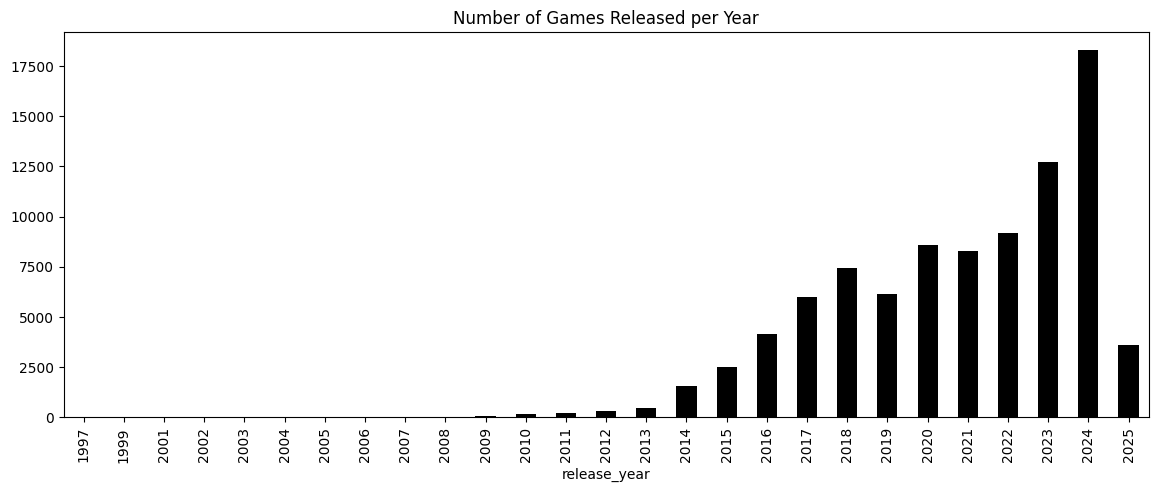

In [20]:
games['release_year'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(14, 5),
    title='Number of Games Released per Year', color = "black"
)

## 5. Review Sentinel Value Assessment and Treatment

Several review-related variables use `-1` to represent unavailable information rather than a valid review statistic. This section quantifies these sentinel values and replaces them with missing values before downstream processing.

In [21]:
review_cols = [
    'pct_pos_total',
    'num_reviews_total',
    'pct_pos_recent',
    'num_reviews_recent'
]

minus_one_summary = pd.DataFrame({
    "-1_count": [(games[col] == -1).sum() for col in review_cols],
    "-1_percentage": [round((games[col] == -1).mean() * 100, 2) for col in review_cols]
}, index=review_cols)

minus_one_summary

,-1_count,-1_percentage
pct_pos_total,36419,40.64
num_reviews_total,36419,40.64
pct_pos_recent,82931,92.54
num_reviews_recent,82931,92.54


### 5.1 Sentinel Value Replacement

In [22]:
for col in review_cols:
    games[col] = games[col].replace(-1, np.nan)

sentinel_check = pd.DataFrame(
    {
        "missing_values": games[review_cols].isna().sum(),
        "remaining_minus_one": [
            (games[col] == -1).sum()
            for col in review_cols
        ],
    }
)

sentinel_check

,missing_values,remaining_minus_one
pct_pos_total,36419,0
num_reviews_total,36419,0
pct_pos_recent,82931,0
num_reviews_recent,82931,0


## 6. Game Title Preparation

A separate display-name field is created for recommendation output and game-title lookup, while the original title field is retained unchanged.

In [23]:
games['display_name'] = games['name']

games[['appid', 'name', 'display_name']].head()

,appid,name,display_name
0,730,Counter-Strike 2,Counter-Strike 2
1,578080,PUBG: BATTLEGROUNDS,PUBG: BATTLEGROUNDS
2,570,Dota 2,Dota 2
3,271590,Grand Theft Auto V Legacy,Grand Theft Auto V Legacy
4,359550,Tom Clancy's Rainbow Six® Siege,Tom Clancy's Rainbow Six® Siege


## 7. Text Cleaning and Normalisation

Text fields are normalised to reduce formatting noise before constructing the metadata and description-based recommendation features.

In [25]:
def clean_text(text):
  """Normalise text by removing HTML, URLs, punctuation and excess whitespace"""
  if pd.isna(text):
        return ""
  text = str(text)
  text = html.unescape(text)                    # converting &amp; to &
  text = re.sub(r'<.*?>', ' ', text)            # removing HTML tags
  text = re.sub(r'http\S+|www\S+', ' ', text)   # removing URLs
  text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)   # removing punctuation/symbols
  text = re.sub(r'\s+', ' ', text).strip()      # removing extra spaces
  text = text.lower()

  return text



In [27]:
# sanity check on one column

sample_text = games["short_description"].sample(
    n=1,
    random_state=42
).iloc[0]

print("Original:")
print(sample_text)

print("\nCleaned:")
print(clean_text(text = sample_text))

Original:
A sci-fi visual novel reimagining The Hound of the Baskervilles (1902). Follow Vornovians Sherr-Lok &amp; Watt-Sun as they try to uncover the truth of the 'curse'

Cleaned:
a sci fi visual novel reimagining the hound of the baskervilles 1902 follow vornovians sherr lok watt sun as they try to uncover the truth of the curse


### 7.1 Application of Text Cleaning Pipeline

The cleaning function is applied consistently to the title, descriptive text and structured metadata fields required by the downstream recommendation models.

In [28]:
text_cols = [
    'name',
    'short_description',
    'about_the_game',
    'detailed_description',
    'genres',
    'categories',
    'tags',
    'developers',
    'publishers'
]

for col in text_cols:
    games[col + '_clean'] = games[col].fillna("").apply(clean_text)

In [29]:
# inspection cell
games[
    [
        'display_name',
        'name_clean',
        'genres_clean',
        'categories_clean',
        'tags_clean',
        'short_description_clean'
    ]
].head()

,display_name,name_clean,genres_clean,categories_clean,tags_clean,short_description_clean
0,Counter-Strike 2,counter strike 2,action free to play,multi player cross platform multiplayer steam ...,fps 90857 shooter 65397 multiplayer 62332 comp...,for over two decades counter strike has offere...
1,PUBG: BATTLEGROUNDS,pubg battlegrounds,action adventure massively multiplayer free to...,multi player pvp online pvp stats remote play ...,survival 14838 shooter 12727 battle royale 108...,play pubg battlegrounds for free land on strat...
2,Dota 2,dota 2,action strategy free to play,multi player co op steam trading cards steam w...,free to play 59933 moba 20158 multiplayer 1535...,every day millions of players worldwide enter ...
3,Grand Theft Auto V Legacy,grand theft auto v legacy,action adventure,single player multi player pvp online pvp co o...,open world 32644 action 23539 multiplayer 2174...,grand theft auto v for pc offers players the o...
4,Tom Clancy's Rainbow Six® Siege,tom clancy s rainbow six siege,action,single player multi player pvp online pvp co o...,fps 9831 pvp 9162 e sports 9072 multiplayer 90...,tom clancy s rainbow six siege is an elite tac...


## 8. Constructing Recommendation Features

Two modelling representations are created from the cleaned text fields:

- `metadata_text` combines structured metadata used by the metadata recommender.
- `combined_text` combines structured metadata with descriptive text for richer text-based modelling.

The original source columns are retained, while the cleaned fields are used to construct these derived representations.

In [30]:
games['metadata_text'] = (
    games['genres_clean'] + " " +
    games['categories_clean'] + " " +
    games['tags_clean']
)

games['combined_text'] = (
    games['name_clean'] + " " +
    games['genres_clean'] + " " +
    games['categories_clean'] + " " +
    games['tags_clean'] + " " +
    games['short_description_clean'] + " " +
    games['about_the_game_clean']
)

In [31]:
print("Empty metadata_text:", (games['metadata_text'].str.strip() == "").sum())
print("Empty combined_text:", (games['combined_text'].str.strip() == "").sum())

Empty metadata_text: 85
Empty combined_text: 2


In [32]:
# sanity check
games[['display_name', 'metadata_text', 'combined_text']].head()

,display_name,metadata_text,combined_text
0,Counter-Strike 2,action free to play multi player cross platfor...,counter strike 2 action free to play multi pla...
1,PUBG: BATTLEGROUNDS,action adventure massively multiplayer free to...,pubg battlegrounds action adventure massively ...
2,Dota 2,action strategy free to play multi player co o...,dota 2 action strategy free to play multi play...
3,Grand Theft Auto V Legacy,action adventure single player multi player pv...,grand theft auto v legacy action adventure sin...
4,Tom Clancy's Rainbow Six® Siege,action single player multi player pvp online p...,tom clancy s rainbow six siege action single p...


## 9. Popularity Feature Transformation

Popularity-related variables are highly skewed because a small number of games receive very large engagement values. These fields are converted to numeric format and log-transformed using `log1p` for later popularity-based modelling and analysis.

In [34]:
popularity_cols = [
    'recommendations',
    'positive',
    'negative',
    'average_playtime_forever',
    'median_playtime_forever',
    'peak_ccu',
    'num_reviews_total'
]

for col in popularity_cols:
    games[col] = pd.to_numeric(games[col], errors='coerce').fillna(0)
    games[f'log_{col}'] = np.log1p(games[col])

In [35]:
games[
    [
        'display_name',
        'recommendations',
        'positive',
        'negative',
        'peak_ccu',
        'num_reviews_total',
        'log_recommendations',
        'log_positive',
        'log_peak_ccu',
        'log_num_reviews_total'
    ]
].head()

,display_name,recommendations,positive,negative,peak_ccu,num_reviews_total,log_recommendations,log_positive,log_peak_ccu,log_num_reviews_total
0,Counter-Strike 2,4401572,7480813,1135108,1212356,8632939.0,15.297473,15.827852,14.008077,15.971096
1,PUBG: BATTLEGROUNDS,1732007,1487960,1024436,616738,2513842.0,14.364792,14.212917,13.332201,14.737323
2,Dota 2,14337,1998462,451338,555977,2452595.0,9.570669,14.507889,13.228484,14.712658
3,Grand Theft Auto V Legacy,1803063,1719950,250012,117698,1803832.0,14.404998,14.357806,11.675886,14.405424
4,Tom Clancy's Rainbow Six® Siege,1165929,1152763,218446,89916,1168020.0,13.969030,13.957673,11.406642,13.970821


## 10. Final Data Quality Validation

The prepared dataset is checked for identifier duplication, missing key fields and empty recommendation-feature representations before export.

In [36]:
print("Shape:", games.shape)
print("Duplicate appids:", games['appid'].duplicated().sum())
print("Missing display_name:", games['display_name'].isna().sum())
print("Missing release_date:", games['release_date'].isna().sum())
print("Missing release_year:", games['release_year'].isna().sum())
print("Empty metadata_text:", (games['metadata_text'].str.strip() == "").sum())
print("Empty combined_text:", (games['combined_text'].str.strip() == "").sum())

Shape: (89618, 50)
Duplicate appids: 0
Missing display_name: 0
Missing release_date: 0
Missing release_year: 0
Empty metadata_text: 85
Empty combined_text: 2


## 11. Save cleaned Dataset

The fully prepared dataset is exported as `games_clean_v1.csv`. This cleaned file serves as the common input for the downstream recommendation notebooks.

In [37]:
# Export the cleaned dataset for downstream recommendation models.

OUTPUT_DIR = DATA_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = OUTPUT_DIR / "games_clean_v1.csv"

games.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Saved successfully to:", OUTPUT_PATH)
print("Final dataset shape:", games.shape)

Saved successfully to: /content/drive/MyDrive/MSC_DISSERTATION/Data/games_clean_v1.csv
Final dataset shape: (89618, 50)
